In [2]:
#Import library
import pandas as pd

In [4]:
#dataset loaded
df=pd.read_csv('/content/Unemployment in India.csv')

**Intial Inspection**

In [5]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
df.shape

(768, 7)

In [9]:
df.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [10]:
df.columns.tolist()

['Region',
 ' Date',
 ' Frequency',
 ' Estimated Unemployment Rate (%)',
 ' Estimated Employed',
 ' Estimated Labour Participation Rate (%)',
 'Area']

**Data Cleaning**

In [11]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()


In [19]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [20]:
# Drop missing rows
df.dropna(inplace=True)

In [21]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


**Statistical Summary**

In [23]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


# **Visualization & Analysis**

In [25]:
#Import Visulization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

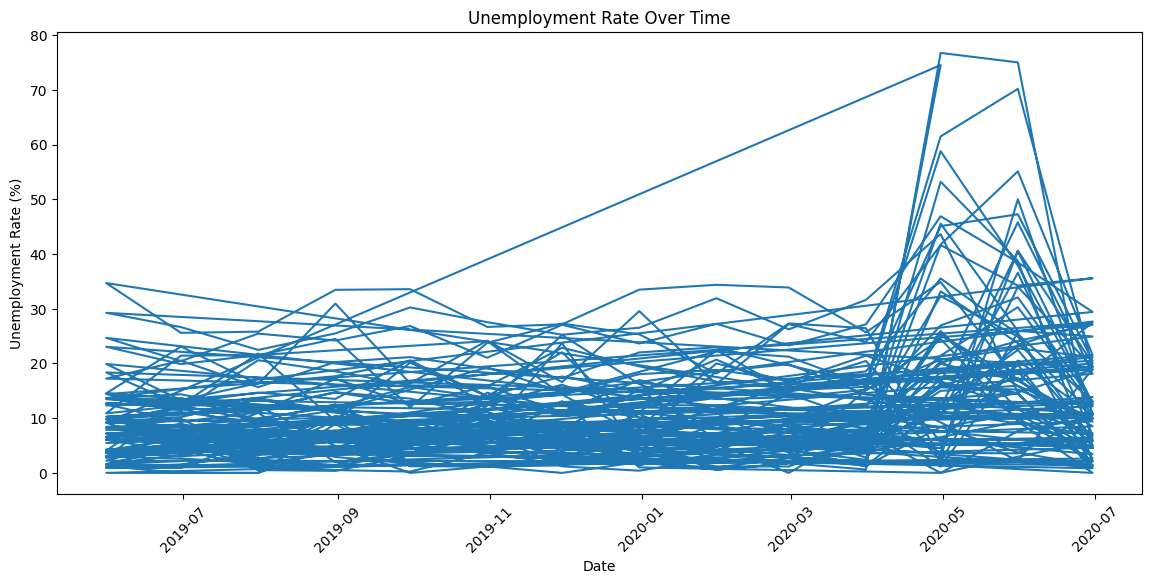

In [27]:
#Overall unemployment trend over time
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

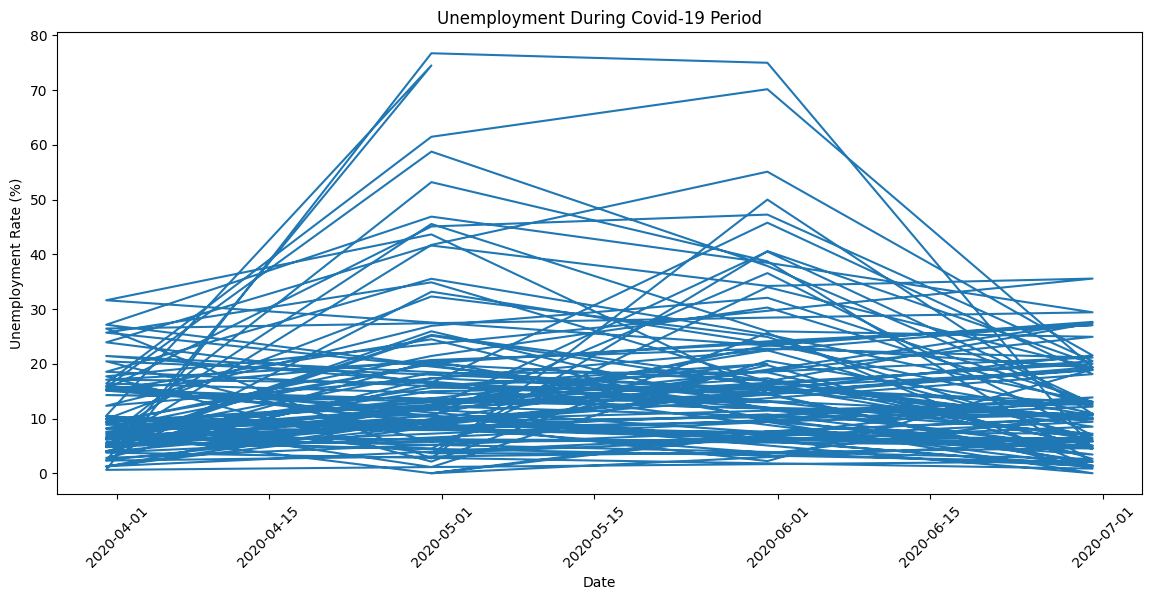

In [28]:
#Covid-19 impact on unemployment
covid_period = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(14,6))
plt.plot(covid_period['Date'], covid_period['Estimated Unemployment Rate (%)'])

plt.title('Unemployment During Covid-19 Period')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

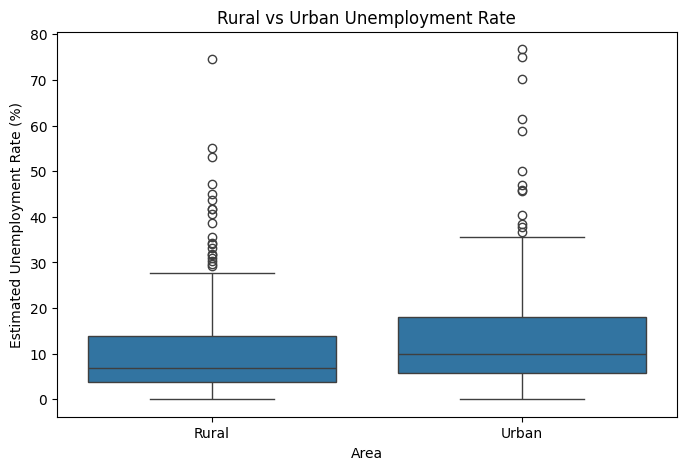

In [29]:
#Rural vs Urban comparison
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title('Rural vs Urban Unemployment Rate')
plt.show()

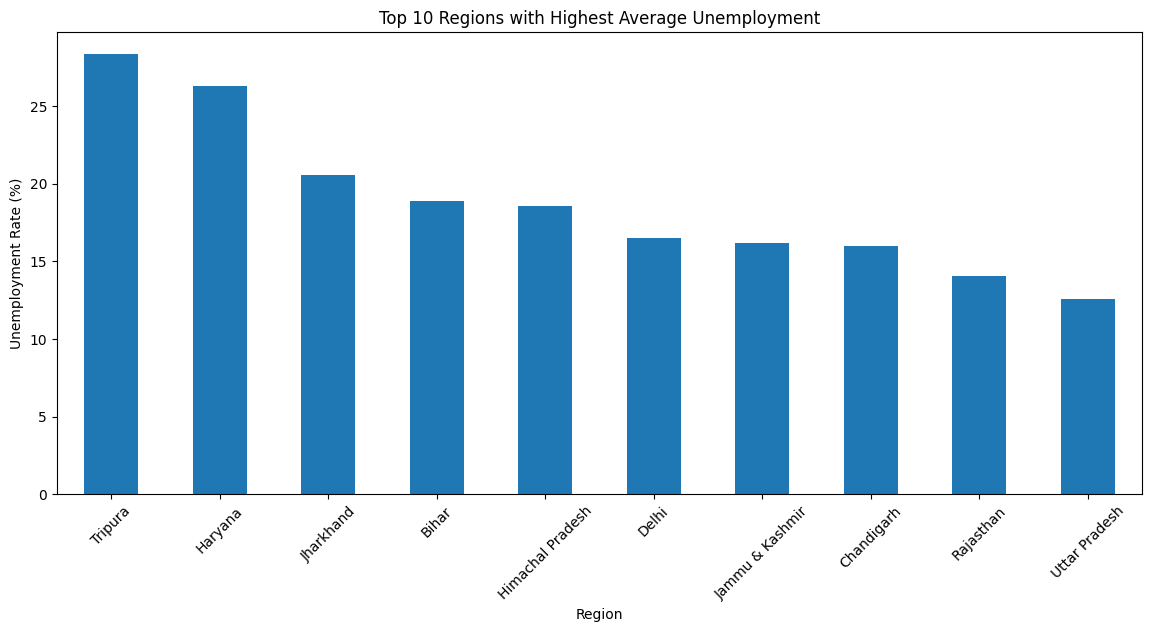

In [30]:
#Top 10 highest unemployment regions
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))
region_unemployment.head(10).plot(kind='bar')

plt.title('Top 10 Regions with Highest Average Unemployment')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

### Key Insights

- A significant unemployment spike was observed after March 2020.
- This suggests a strong impact of Covid-19 on employment.
- Urban unemployment was generally higher than rural unemployment.
- Tripura recorded the highest average unemployment rate.
- The dataset indicates clear regional disparities in unemployment trends.

### Conclusion

This analysis shows that unemployment trends were significantly influenced by the Covid-19 pandemic.
The sharp rise after March 2020 highlights the economic disruption caused by lockdown measures.

Urban regions experienced greater unemployment pressure compared to rural areas, suggesting that service-based economies were more vulnerable.

Regional differences, especially Tripura's high unemployment, emphasize the need for targeted employment policies and economic recovery strategies.

In [32]:
print("Dataset Shape:", df.shape)
print("Analysis Completed Successfully")

Dataset Shape: (740, 7)
Analysis Completed Successfully
